2026-07-01 18:29:04.028 | INFO     | __main__:reducer_node:51 - reducer shuffle entries:{'hello': [1, 1, 1], 'world': [1], 'atguigu': [1], 'llm': [1]}
2026-07-01 18:29:04.029 | INFO     | __main__:reducer_node:57 - reducer {'hello': 3, 'world': 1, 'atguigu': 1, 'llm': 1}


{'input_values': ['hello world', 'hello atguigu', 'hello llm'], 'entries': [('hello', 1), ('world', 1), ('hello', 1), ('atguigu', 1), ('hello', 1), ('llm', 1)], 'word_counts': {'hello': 3, 'world': 1, 'atguigu': 1, 'llm': 1}}


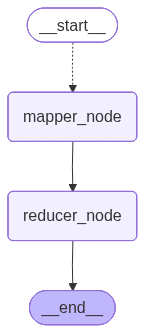

In [3]:
from typing import TypedDict, Annotated, Sequence

from langgraph.constants import START,END
from langgraph.graph import StateGraph
from langgraph.types import Send
from operator import add
from loguru import logger
#1. 声明状态
#1.1 声明全局状态
class OverAllState(TypedDict):
    input_values: list[str]
    entries:Annotated[list[tuple[str,int]],add]
    word_counts:dict[str,int]

class MaperInputState(TypedDict):
    input_value:str

#2. 声明节点
#2.1 分发节点
def router_node(state:OverAllState)-> Sequence[Send]:
    input_values = state["input_values"]
    task = []
    for input_value in input_values:
        task.append(
            Send("mapper_node",{"input_value":input_value})
        )
    return task
#2.2 接收单独的一句话, 切分为单词  组装为元组放到全局状态中
def mapper_node(state:MaperInputState) -> OverAllState:
    input_value = state["input_value"]
    words = input_value.split(" ")
    #  (hello, 1), (world, 1)
    entries = []
    for word in words:
        entries.append((word,1))
    return {
        "entries":entries
    }

#2.3 聚合所有的mapper_node拆分的元组进行合并
def reducer_node(state:OverAllState) -> OverAllState:
    entries = state["entries"]
    shuffle_dict = {}
    # hello   -> [1, 1, 1]
    for k,v in entries:
        if k not in shuffle_dict:
            shuffle_dict[k] = [v]
        else:
            shuffle_dict[k].append(v)

    logger.info("reducer shuffle entries:{}",shuffle_dict)
    reduce_dict = {}

    for k,v in shuffle_dict.items():
        reduce_dict[k] = sum(v)

    logger.info("reducer {}",reduce_dict)

    return {
        "word_counts":reduce_dict
    }

#3. 构件图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("mapper_node",mapper_node)
builder.add_node("reducer_node",reducer_node)
builder.add_conditional_edges(START,router_node,path_map=["mapper_node"])
builder.add_edge("mapper_node","reducer_node")
builder.add_edge("reducer_node",END)
graph = builder.compile()

res = graph.invoke({
    "input_values":["hello world","hello atguigu","hello llm"]
})
print(res)

from IPython.display import display
display(graph)

